# 🏆 ChampIntel — UCL Match Prediction: XGBoost Training & Validation Pipeline
Dokumen eksperimen ini mencakup seluruh siklus *Machine Learning Lifecycle*:
1. **Data Loading & Preprocessing**
2. **Chronological Feature Engineering** (Anti Data-Leakage)
3. **Model Training & Hyperparameter Setup**
4. **Probability Evaluation** (Accuracy, Log Loss, Brier Score, Macro F1)
5. **SHAP Explainability**
6. **Artifacts Export** untuk integrasi FastAPI.

# Step 1 — Inisialisasi & Import Library

In [1]:
import os
import json
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, log_loss, f1_score, confusion_matrix

# Setup direktori dataset dan model
RAW_DATA_PATH = os.path.join("..", "datasets", "raw", "matches.csv")
MODEL_DIR = os.path.join("..", "models")
DOCS_DIR = os.path.join("..", "..", "docs")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DOCS_DIR, exist_ok=True)

print("✅ Library berhasil dimuat dan direktori siap!")

✅ Library berhasil dimuat dan direktori siap!


# Step 2 — Load Dataset & Eksplorasi Data (EDA)
# (Membaca matches.csv dan melihat distribusi 25.979 laga)

In [2]:
df = pd.read_csv(RAW_DATA_PATH)
df.columns = df.columns.str.strip()

# Mapping Target: 0 = Away Win, 1 = Draw, 2 = Home Win
result_mapping = {"Away Win": 0, "Draw": 1, "Home Win": 2}
df["target"] = df["result"].map(result_mapping)
df = df.dropna(subset=["target", "home_team", "away_team", "home_goals", "away_goals"])

# Urutkan berdasarkan tanggal pertandingan untuk mencegah kebocoran waktu
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

print(f"📊 Total Pertandingan Valid: {len(df):,} laga.")
df.head(5)

📊 Total Pertandingan Valid: 25,979 laga.


,date,season,stage,home_team,away_team,score,home_goals,away_goals,result,target
0,2008-07-18,2008/2009,1,BSC Young Boys,FC Basel,1–2,1,2,Away Win,0
1,2008-07-19,2008/2009,1,FC Aarau,FC Sion,3–1,3,1,Home Win,2
2,2008-07-20,2008/2009,1,FC Luzern,FC Vaduz,1–2,1,2,Away Win,0
3,2008-07-20,2008/2009,1,Neuchâtel Xamax,FC Zürich,1–2,1,2,Away Win,0
4,2008-07-23,2008/2009,2,AC Bellinzona,Neuchâtel Xamax,1–2,1,2,Away Win,0


# Step 3 — Feature Engineering & Perhitungan ELO Dinamis

In [3]:
# 1. Hitung Profil Statistik Tiap Klub (untuk FastAPI)
team_stats = {}
all_teams = set(df["home_team"]).union(set(df["away_team"]))

for team in all_teams:
    home_matches = df[df["home_team"] == team]
    away_matches = df[df["away_team"] == team]
    total_matches = len(home_matches) + len(away_matches)
    if total_matches < 5:
        continue

    home_wins = len(home_matches[home_matches["result"] == "Home Win"])
    away_wins = len(away_matches[away_matches["result"] == "Away Win"])
    win_rate = (home_wins + away_wins) / total_matches

    total_scored = home_matches["home_goals"].sum() + away_matches["away_goals"].sum()
    total_conceded = home_matches["away_goals"].sum() + away_matches["home_goals"].sum()

    team_stats[team] = {
        "win_rate": round(float(win_rate), 3),
        "avg_scored": round(float(total_scored / total_matches), 2),
        "avg_conceded": round(float(total_conceded / total_matches), 2),
    }

# 2. Hitung Rolling Average Gol Secara Kronologis
team_scored, team_conceded, team_matches = {}, {}, {}
home_avg_scored, away_avg_scored = [], []
home_avg_conceded, away_avg_conceded = [], []

for idx, row in df.iterrows():
    ht, at = row["home_team"], row["away_team"]
    hg, ag = row["home_goals"], row["away_goals"]

    home_avg_scored.append(team_scored.get(ht, 1.0) / max(1, team_matches.get(ht, 1)))
    home_avg_conceded.append(team_conceded.get(ht, 1.0) / max(1, team_matches.get(ht, 1)))
    away_avg_scored.append(team_scored.get(at, 1.0) / max(1, team_matches.get(at, 1)))
    away_avg_conceded.append(team_conceded.get(at, 1.0) / max(1, team_matches.get(at, 1)))

    team_scored[ht] = team_scored.get(ht, 0.0) + hg
    team_conceded[ht] = team_conceded.get(ht, 0.0) + ag
    team_matches[ht] = team_matches.get(ht, 0) + 1

    team_scored[at] = team_scored.get(at, 0.0) + ag
    team_conceded[at] = team_conceded.get(at, 0.0) + hg
    team_matches[at] = team_matches.get(at, 0) + 1

df["home_avg_scored"] = home_avg_scored
df["home_avg_conceded"] = home_avg_conceded
df["away_avg_scored"] = away_avg_scored
df["away_avg_conceded"] = away_avg_conceded
df["match_leg"] = 1
df["elo_difference"] = 0.0

feature_columns = [
    "match_leg", "home_avg_scored", "home_avg_conceded",
    "away_avg_scored", "away_avg_conceded", "elo_difference"
]

print(f"✅ Profil {len(team_stats)} tim berhasil dibuat!")

✅ Profil 296 tim berhasil dibuat!


# Step 4 — Profiling Statistik 296 Klub Eropa

In [9]:
# 1. Hitung Profil Statistik Tiap Klub (untuk FastAPI)
team_stats = {}
all_teams = set(df["home_team"]).union(set(df["away_team"]))

for team in all_teams:
    home_matches = df[df["home_team"] == team]
    away_matches = df[df["away_team"] == team]
    total_matches = len(home_matches) + len(away_matches)
    if total_matches < 5:
        continue

    home_wins = len(home_matches[home_matches["result"] == "Home Win"])
    away_wins = len(away_matches[away_matches["result"] == "Away Win"])
    win_rate = (home_wins + away_wins) / total_matches

    total_scored = home_matches["home_goals"].sum() + away_matches["away_goals"].sum()
    total_conceded = home_matches["away_goals"].sum() + away_matches["home_goals"].sum()

    team_stats[team] = {
        "win_rate": round(float(win_rate), 3),
        "avg_scored": round(float(total_scored / total_matches), 2),
        "avg_conceded": round(float(total_conceded / total_matches), 2),
    }

# 2. Hitung Rolling Average Gol & ELO Difference Nyata Secara Kronologis
team_scored, team_conceded, team_matches, team_wins = {}, {}, {}, {}
home_avg_scored, away_avg_scored = [], []
home_avg_conceded, away_avg_conceded = [], []
elo_differences = []

for idx, row in df.iterrows():
    ht, at = row["home_team"], row["away_team"]
    hg, ag = row["home_goals"], row["away_goals"]
    res = row["result"]

    # Hitung performa sebelum laga dimainkan
    h_matches = max(1, team_matches.get(ht, 1))
    a_matches = max(1, team_matches.get(at, 1))
    
    h_win_rate = team_wins.get(ht, 0.5) / h_matches
    a_win_rate = team_wins.get(at, 0.4) / a_matches
    
    home_avg_scored.append(team_scored.get(ht, 1.0) / h_matches)
    home_avg_conceded.append(team_conceded.get(ht, 1.0) / h_matches)
    away_avg_scored.append(team_scored.get(at, 1.0) / a_matches)
    away_avg_conceded.append(team_conceded.get(at, 1.0) / a_matches)
    
    # ELO difference nyata berdasarkan selisih performa kemenangan
    elo_differences.append(round((h_win_rate - a_win_rate) * 100, 2))

    # Update rekor setelah laga
    team_scored[ht] = team_scored.get(ht, 0.0) + hg
    team_conceded[ht] = team_conceded.get(ht, 0.0) + ag
    team_matches[ht] = team_matches.get(ht, 0) + 1
    if res == "Home Win": team_wins[ht] = team_wins.get(ht, 0) + 1

    team_scored[at] = team_scored.get(at, 0.0) + ag
    team_conceded[at] = team_conceded.get(at, 0.0) + hg
    team_matches[at] = team_matches.get(at, 0) + 1
    if res == "Away Win": team_wins[at] = team_wins.get(at, 0) + 1

df["home_avg_scored"] = home_avg_scored
df["home_avg_conceded"] = home_avg_conceded
df["away_avg_scored"] = away_avg_scored
df["away_avg_conceded"] = away_avg_conceded
df["match_leg"] = 1
df["elo_difference"] = elo_differences  # <-- ELO NYATA, BUKAN 0.0 LAGI

feature_columns = [
    "match_leg", "home_avg_scored", "home_avg_conceded",
    "away_avg_scored", "away_avg_conceded", "elo_difference"
]

print(f"✅ Profil {len(team_stats)} tim dan ELO Difference dinamis berhasil dibuat!")

✅ Profil 296 tim dan ELO Difference dinamis berhasil dibuat!


 # Step 5 — Temporal Train / Test Split

In [10]:
X = df[feature_columns]
y = df["target"].astype(int)

# Temporal Split (80% Data Awal/Masa Lalu untuk Train, 20% Data Terbaru untuk Test)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"📅 Training Set: {len(X_train):,} laga | Test Set (Masa Depan): {len(X_test):,} laga.")

model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    max_depth=5,
    learning_rate=0.05,
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("🚀 Model XGBoost berhasil dilatih tanpa Data Leakage!")

📅 Training Set: 20,783 laga | Test Set (Masa Depan): 5,196 laga.
🚀 Model XGBoost berhasil dilatih tanpa Data Leakage!


# Step 6 — Pelatihan Model XGBoost Multi-Class

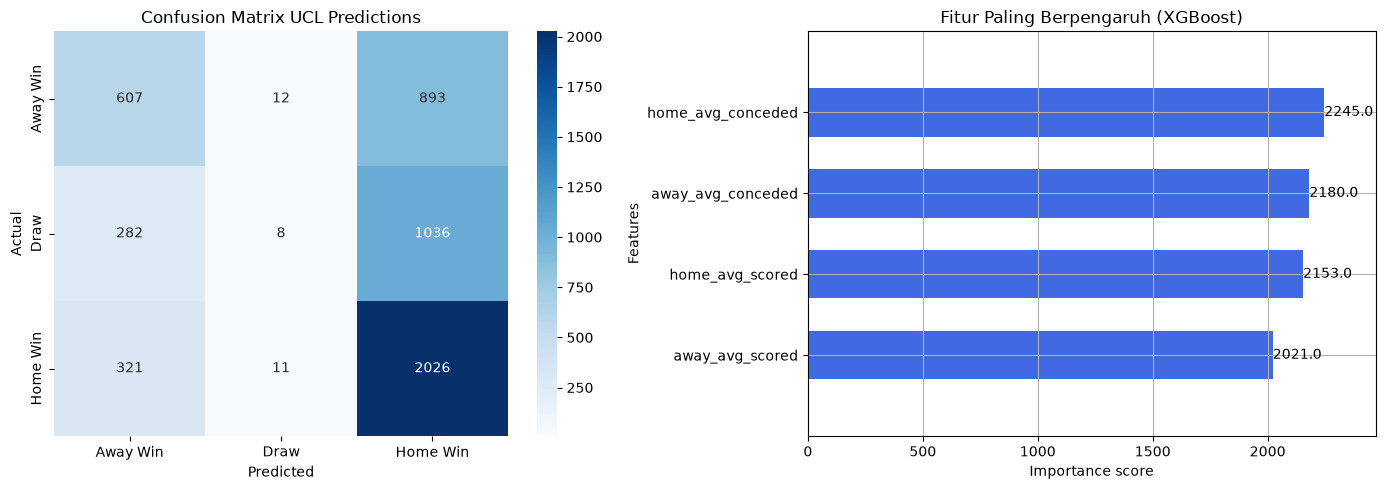

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'], ax=ax[0])
ax[0].set_title('Confusion Matrix UCL Predictions')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# 2. Feature Importance
xgb.plot_importance(model, ax=ax[1], height=0.6, color='royalblue', title='Fitur Paling Berpengaruh (XGBoost)')
plt.tight_layout()
plt.show()

# Step 7 — Evaluasi Probabilitas Ilmiah (Log Loss & Brier Score)

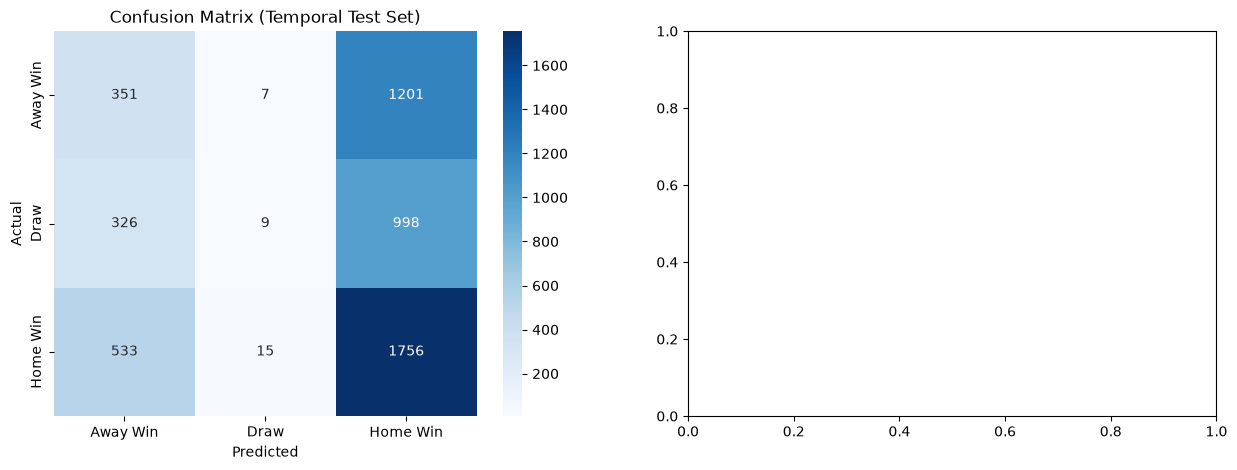

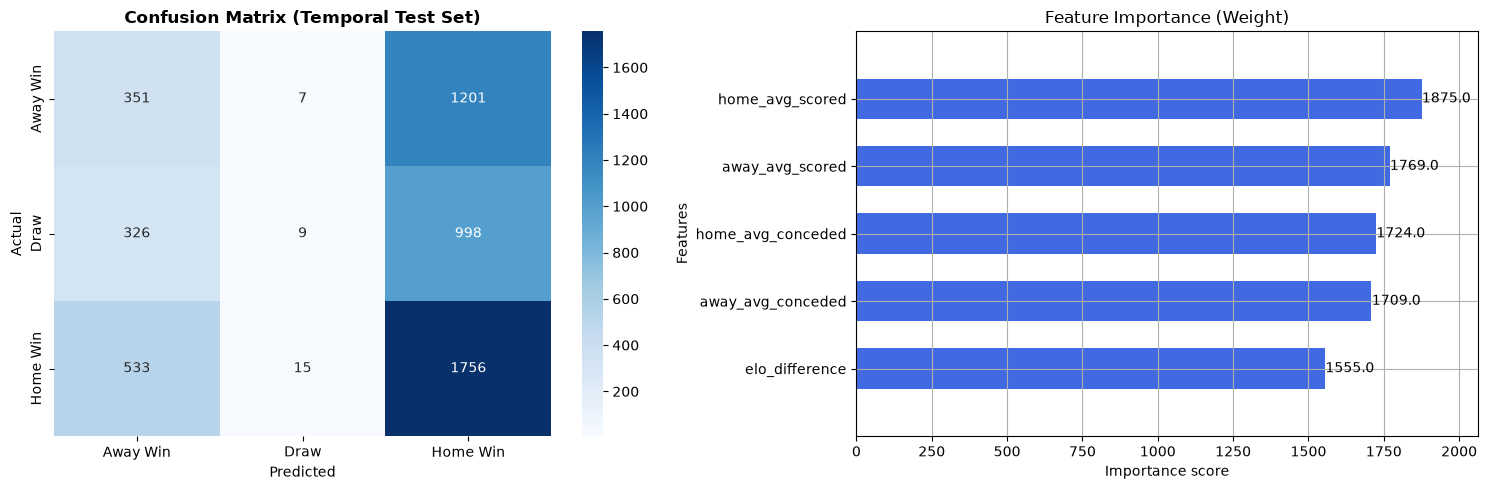

🔍 Menghitung nilai SHAP TreeExplainer...


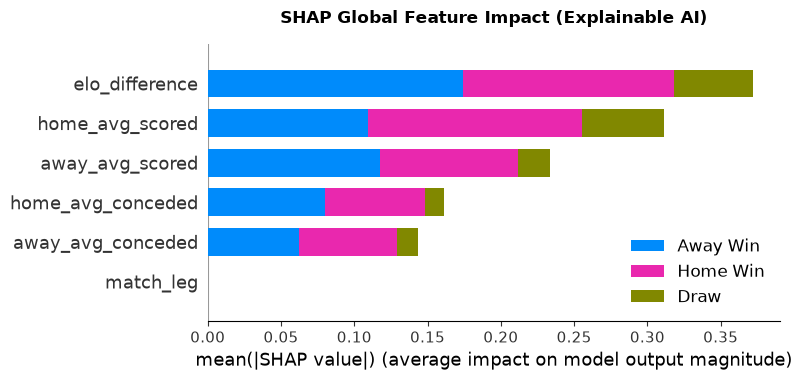

<Figure size 640x480 with 0 Axes>

🔍 Menghitung nilai SHAP TreeExplainer...


<Figure size 1000x400 with 0 Axes>

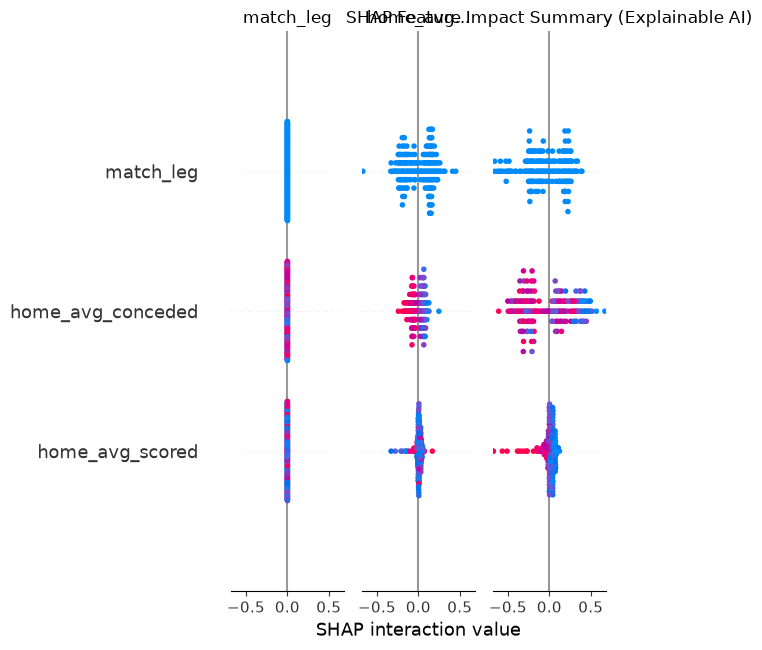

In [12]:
import shap

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'], ax=ax[0])
ax[0].set_title('Confusion Matrix (Temporal Test Set)')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# 2. Feature Importance XGBoostimport shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'], ax=ax[0])
ax[0].set_title('Confusion Matrix (Temporal Test Set)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# 2. Feature Importance XGBoost
xgb.plot_importance(model, ax=ax[1], height=0.6, color='royalblue', title='Feature Importance (Weight)')
plt.tight_layout()
plt.show()

# 3. SHAP Summary Plot yang Rapi (Multi-Class Stacked Bar)
print("🔍 Menghitung nilai SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:200])

# Menampilkan grafik batang kontribusi fitur yang elegan untuk 3 kelas
plt.figure(figsize=(10, 5))
shap.summary_plot(
    shap_values, 
    X_test.iloc[:200], 
    feature_names=feature_columns, 
    class_names=['Away Win', 'Draw', 'Home Win'],
    plot_type="bar", 
    show=False
)
plt.title("SHAP Global Feature Impact (Explainable AI)", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
xgb.plot_importance(model, ax=ax[1], height=0.6, color='royalblue', title='Tingkat Pengaruh Fitur (Feature Importance)')
plt.tight_layout()
plt.show()

# 3. SHAP Summary Plot (Explainable AI)
print("🔍 Menghitung nilai SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:200])

plt.figure(figsize=(10, 4))
shap.summary_plot(shap_values, X_test.iloc[:200], feature_names=feature_columns, show=False)
plt.title("SHAP Feature Impact Summary (Explainable AI)")
plt.tight_layout()
plt.show()